Filename: m101.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     125   (530, 530)   int16   
  1  Photometric CALTABLE    1 BinTableHDU     39   16R x 4C   [1D, 1D, 1D, 1J]   

SIMPLE: True
BITPIX: 16
NAXIS: 2
NAXIS1: 530
NAXIS2: 530

shape: (530, 530)
dtype: >i2

minimum = 1507
maximum = 15752
mean = 4795.924268422927
std = 1848.2526085366376
median = 4102.0
mode = 3551


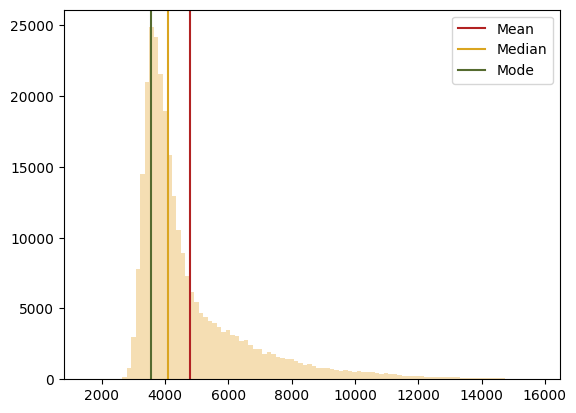

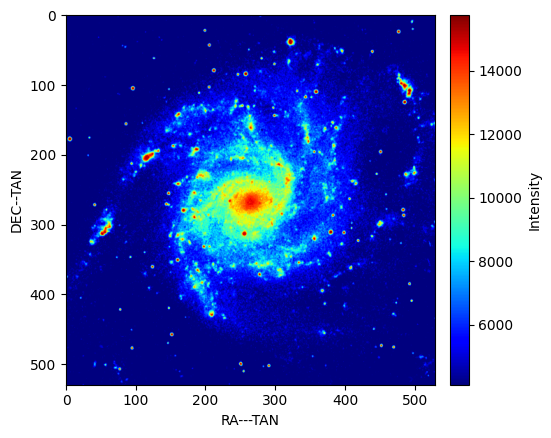

 [astropy.io.fits.verify]


In [9]:
#6.1

from astropy.io import fits
from scipy import stats
import numpy as np
from matplotlib.pyplot import figure, show
from mpl_toolkits.axes_grid1 import make_axes_locatable

m101 = fits.open('m101.fits')
m101.info()
print()

#2 HDUs
#PRIMARY contains image data, index 0
#number type int16

hdr = m101[0].header
for key in hdr[:5]:
    print(f'{key}: {hdr[key]}')
print()

dat = m101[0].data
print(f'shape: {dat.shape}')
print(f'dtype: {dat.dtype}')
print()

flatdat = dat.flat
print(f'minimum = {np.min(flatdat)}')
print(f'maximum = {np.max(flatdat)}')
print(f'mean = {np.mean(flatdat)}')
print(f'std = {np.std(flatdat)}')
print(f'median = {np.median(flatdat)}')
#s = stats.describe(flatdat)
#print(s)
mode, counts = stats.mode(flatdat)
print(f'mode = {mode}')

#plotting histogram
fig = figure()
frame = fig.add_subplot(1,1,1)
frame.hist(flatdat,bins=100,color='wheat')
frame.axvline(np.mean(flatdat),color='firebrick',label='Mean')
frame.axvline(np.median(flatdat),color='goldenrod',label='Median')
frame.axvline(mode,color='darkolivegreen',label='Mode')
frame.legend()
show()

#plotting image
image = np.asarray(dat)
median = np.median(image)
fig = figure()
frame2 = fig.add_subplot(1,1,1)
a = frame2.imshow(image, cmap='jet', vmin=median)

divider = make_axes_locatable(frame2)
colbarframe = divider.append_axes("right", size="5%", pad=0.15)

frame2.set_xlabel(hdr['CTYPE1'])
frame2.set_ylabel(hdr['CTYPE2'])
fig.colorbar(a,ax=frame2,label='Intensity',cax=colbarframe)
show()

hdr['BUNIT'] = 'Counts'
m101new = fits.PrimaryHDU(dat)
m101new.header = hdr
m101new.writeto('m101new.fits',overwrite=True,output_verify='ignore')

m101.close()

In [2]:
#6.3

bg = image[0:21,0:21]
bg_flat = bg.flatten()

#fig = figure()
#frame = fig.add_subplot(1,1,1)
#frame.imshow(bg)

rms = 0
for i in bg_flat:
    rms += i**2
rms = rms/len(bg_flat)
rms = rms**(1/2)
print(f'rms = {rms}')

mean = np.mean(bg_flat)
print(f'mean = {mean}')

std = np.std(bg_flat)
print(f'std = {std}')

#rms squares data points
#std squares difference between data points and mean
#which is better for noise???

rms = 3419.889724190472
mean = 3409.875283446712
std = 261.5268188212982


std0 = 9.984, std1 = 10.004, std2 = 9.995
mean image std = 5.773
other std = 5.770


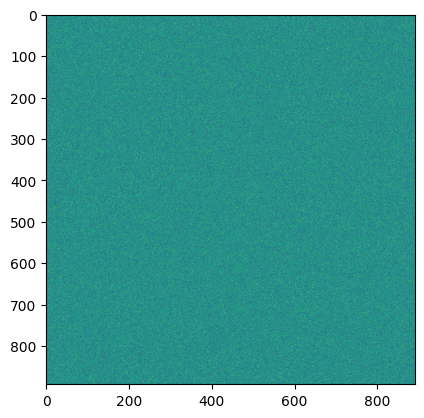

In [3]:
#6.5

map0 = fits.open('noisemap0.fits')
map1 = fits.open('noisemap1.fits')
map2 = fits.open('noisemap2.fits')

dat0 = np.asarray(map0[0].data)
dat1 = np.asarray(map1[0].data)
dat2 = np.asarray(map2[0].data)

std0 = np.std(dat0)
std1 = np.std(dat1)
std2 = np.std(dat2)

print(f'std0 = {std0:.3f}, std1 = {std1:.3f}, std2 = {std2:.3f}')

d3 = np.stack((dat0,dat1,dat2),axis=0)

meanim = np.mean(d3,axis=0)

fig = figure()
frame = fig.add_subplot(1,1,1)
frame.imshow(meanim)

stdmean = np.std(meanim)
print(f'mean image std = {stdmean:.3f}')

stdother = ((std0**2 + std1**2 + std2**2)**(1/2))/3
print(f'other std = {stdother:.3f}')

In [72]:
#6.6

from astropy.table import QTable

hdul = fits.open('APOGEE_stars.fits')

data = hdul[1].data
colnames = hdul[1].columns.names

table = QTable(data)

#filter data according to given conditions
mask = (
    (table['STARFLAG'] == 0) &
    (table['ASPCAPFLAG'] == 0) & (table['SNR'] > 10) &
    (table['GAIAEDR3_PARALLAX']/table['GAIAEDR3_PARALLAX_ERROR'] > 5) &
    (~np.isnan(table['GAIAEDR3_PHOT_G_MEAN_MAG'])) &
    (~np.isnan(table['GAIAEDR3_PHOT_BP_MEAN_MAG'])) &
    (~np.isnan(table['GAIAEDR3_PHOT_RP_MEAN_MAG'])))

table['DATAFLAG'] = np.where(mask, 1, 0)
#print(table)

apparent = table['GAIAEDR3_PHOT_G_MEAN_MAG']
parallax = table['GAIAEDR3_PARALLAX']
distance = np.where(parallax>0,parallax/1000,np.nan)
absolute = apparent + 5*np.log10(distance) + 5

mask2 = ((table['DATAFLAG'] == 0))
table['ABS_MAG'] = np.where(mask2,-1,absolute)

table.write('APOGEE_update.fits',overwrite=True)

newapogee = fits.open('APOGEE_update.fits')
newtable = QTable(newapogee[1].data)
newtable

GAIAEDR3_PARALLAX,GAIAEDR3_PARALLAX_ERROR,GAIAEDR3_PHOT_G_MEAN_MAG,GAIAEDR3_PHOT_BP_MEAN_MAG,GAIAEDR3_PHOT_RP_MEAN_MAG,ASPCAPFLAG,STARFLAG,SNR,DATAFLAG,ABS_MAG
float32,float32,float32,float32,float32,int64,int64,float32,int64,float32
nan,nan,nan,nan,nan,133,0,418.9276,0,-1.0
0.28544167,0.019475,11.6988,13.2722,10.4956,0,3072,827.1565,0,-1.0
0.08209286,0.315081,12.2882,12.5149,11.6597,68,0,229.87506,0,-1.0
1.2985312,0.00952245,12.2209,12.65,11.6189,0,512,121.3259,0,-1.0
1.2985312,0.00952245,12.2209,12.65,11.6189,0,0,221.82442,1,2.7881622
-0.02394128,0.0450072,16.7478,17.3861,15.9896,0,0,35.325546,0,-1.0
1.3863556,0.0175672,12.2759,12.8311,11.5693,0,0,294.87552,1,2.9852724
2.084405,0.0180373,12.2821,12.5812,11.8179,68,0,126.0876,0,-1.0
0.12760994,0.0295789,15.551,16.4267,14.6271,0,50331652,116.9411,0,-1.0


Max of phot_g_mean_flux: 42489404.0


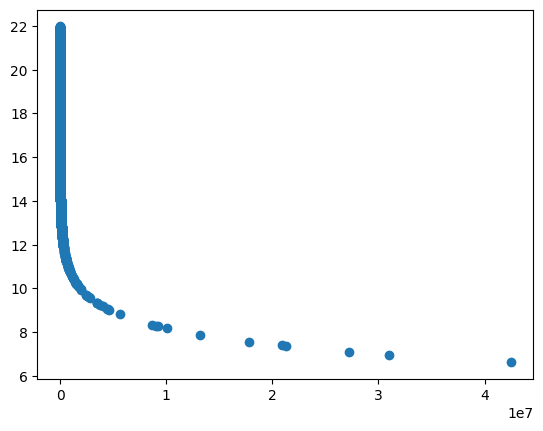

m0 = 25.69


In [42]:
#6.7

import pandas as pd

gaia = pd.read_csv('gaiaTestData.csv')
maxg = gaia.phot_g_mean_flux.max()
print(f'Max of phot_g_mean_flux: {maxg}')
rowg = gaia.index[gaia['phot_g_mean_flux'] == maxg][0]
#print(gaia.iloc[[64]])
gaia.sort_values(by=['phot_g_mean_flux'])

fig = figure()
frame = fig.add_subplot(1,1,1)
x = gaia['phot_g_mean_flux']
y = gaia['phot_g_mean_mag']   #other way around
frame.scatter(x,y)
show()

m0 = y + 2.5*np.log10(x)
m0mean = m0.mean()
print(f'm0 = {m0mean:.2f}')

In [1]:
#6.10

from astroquery.gaia import Gaia

#dr3 = Gaia.load_table('gaiadr3.gaia_source')

query1 = """SELECT
TOP 50
source_id, ra, dec, parallax, parallax_error, phot_g_mean_mag, phot_bp_mean_mag, phot_rp_mean_mag
FROM gaiadr3.gaia_source
WHERE parallax/parallax_error > 5 
    AND phot_g_mean_mag IS NOT NULL
    AND phot_bp_mean_mag IS NOT NULL
    AND phot_rp_mean_mag IS NOT NULL
ORDER BY random_index
"""

job = Gaia.launch_job(query1)
results = job.get_results()
results

ModuleNotFoundError: No module named 'astroquery'

In [83]:
#6.14

class Fibonacci:
    """Class for calculating Fibonacci sequence"""
    
    def __init__(self, N, M):
        self.N = N
        self.M = M
        
    def nterm(self):
        a = 0
        b = 1
        terms = [0,1]
        for i in range(self.N-2):
            c = a+b
            terms += [c]
            a = b
            b = c
        return terms
    
    def divmterm(self):
        nterms = self.nterm()
        terms2 = []
        for i in nterms:
            try:
                if i%self.M == 0:
                    terms2 += [i]
            except ZeroDivisionError:
                print("Cannot divide by zero.")
                break
        return terms2

test = Fibonacci(100,7)
print(test.nterm())
print(test.divmterm())

[0, 1, 1, 2, 3, 5, 8, 13, 21, 34, 55, 89, 144, 233, 377, 610, 987, 1597, 2584, 4181, 6765, 10946, 17711, 28657, 46368, 75025, 121393, 196418, 317811, 514229, 832040, 1346269, 2178309, 3524578, 5702887, 9227465, 14930352, 24157817, 39088169, 63245986, 102334155, 165580141, 267914296, 433494437, 701408733, 1134903170, 1836311903, 2971215073, 4807526976, 7778742049, 12586269025, 20365011074, 32951280099, 53316291173, 86267571272, 139583862445, 225851433717, 365435296162, 591286729879, 956722026041, 1548008755920, 2504730781961, 4052739537881, 6557470319842, 10610209857723, 17167680177565, 27777890035288, 44945570212853, 72723460248141, 117669030460994, 190392490709135, 308061521170129, 498454011879264, 806515533049393, 1304969544928657, 2111485077978050, 3416454622906707, 5527939700884757, 8944394323791464, 14472334024676221, 23416728348467685, 37889062373143906, 61305790721611591, 99194853094755497, 160500643816367088, 259695496911122585, 420196140727489673, 679891637638612258, 110008777